In [ ]:

import os
import kagglehub
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.utils import image_dataset_from_directory

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Conv2D,
    MaxPooling2D,
    Rescaling,
    GlobalAveragePooling2D
)

path = kagglehub.dataset_download(
    "bhavikjikadara/dog-and-cat-classification-dataset"
)

print("Dataset path:")
print(path)

dataset_path = os.path.join(
    path,
    "PetImages"
)

print("\nClasses folders:")
print(os.listdir(dataset_path))

train_data = image_dataset_from_directory(dataset_path,
                                          validation_split=0.2,
                                          subset="training",
                                          seed=42,
                                          image_size=(180, 180),
                                          batch_size=64,
                                          color_mode="rgb")

val_data = image_dataset_from_directory(dataset_path,
                                        validation_split=0.2,
                                        subset="validation",
                                        seed=42,
                                        image_size=(180, 180),
                                        batch_size=64,
                                        color_mode="rgb")

print("\nClass names:")
print(train_data.class_names)


#IGNORE CORRUPTED / INVALID IMAGES
train_data = train_data.ignore_errors()

val_data = val_data.ignore_errors()


#DATA AUGMENTATION

data_augmentation = tf.keras.Sequential([tf.keras.layers.RandomFlip("horizontal"),
                                         tf.keras.layers.RandomRotation(0.1),
                                         tf.keras.layers.RandomZoom(0.1)])


#BUILD CNN MODEL

model = tf.keras.Sequential([Input(shape=(180, 180, 3)),
                             data_augmentation,
                             # Pixel values: 0-255 → 0-1
                             Rescaling(1./255),
                             Conv2D(32,(3, 3),activation="relu"),
                             MaxPooling2D(),
                             Conv2D(64,(3,3),activation="relu"),
                             MaxPooling2D(),
                             Conv2D(128,(3,3),activation="relu"),
                             MaxPooling2D(),
                             GlobalAveragePooling2D(),
                             Dense(128,activation="relu"),
                             Dropout(0.3),
                             Dense(1,activation="sigmoid")])


#MODEL SUMMARY

model.summary()


#COMPILE MODEL

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"])


#EARLY STOPPING

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True)


#TRAIN MODEL
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop])


#EVALUATE MODEL
loss, accuracy = model.evaluate(val_data)
print("MODEL RESULTS")
print(f"Validation Loss: {loss:.4f}")

print(f"Validation Accuracy: {accuracy * 100:.2f}%")


Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Dataset path:
/kaggle/input/dog-and-cat-classification-dataset

Classes folders:
['Dog', 'Cat']
Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.

Class names:
['Cat', 'Dog']


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_10 (Sequential)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 39s 121ms/step - accuracy: 0.5568 - loss: 0.6782 - val_accuracy: 0.6166 - val_loss: 0.6503
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 37s 120ms/step - accuracy: 0.6249 - loss: 0.6475 - val_accuracy: 0.6695 - val_loss: 0.6107
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 38s 125ms/step - accuracy: 0.6681 - loss: 0.6137 - val_accuracy: 0.7042 - val_loss: 0.5817
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 37s 121ms/step - accuracy: 0.6910 - loss: 0.5870 - val_accuracy: 0.7159 - val_loss: 0.5594
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 37s 120ms/step - accuracy: 0.7041 - loss: 0.5725 - val_accuracy: 0.7331 - val_loss: 0.5454
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 37s 120ms/step - accuracy: 0.7160 - loss: 0.5589 - val_accuracy: 0.7386 - val_loss: 0.5432
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 37s 121ms/step - accuracy: 0.7190 - loss: 0.5528 - val_accuracy: 0.7481 - val_loss: 0.5272
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 37s 121ms/step - accuracy: 0.7244 - loss: 0

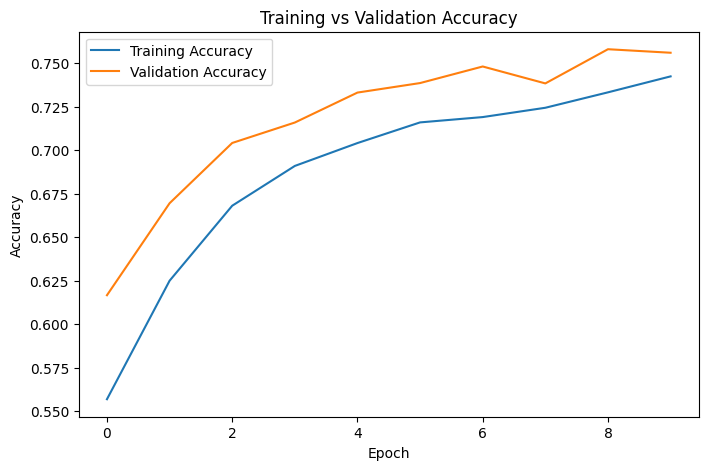

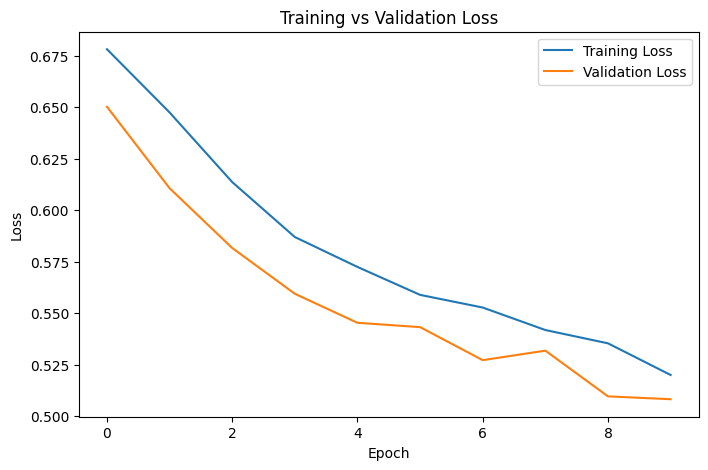


Model saved successfully!


In [ ]:

#ACCURACY GRAPH

plt.figure(figsize=(8, 5))
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


# LOSS GRAPH
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

#SAVE MODEL

model.save("cats_dogs_cnn.keras")

print("\nModel saved successfully!")

In [ ]:
#PREDICT A NEW IMAGE

import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

def predict_image(image_path):
    # Load image

    img = load_img(
        image_path,
        target_size=(180, 180)
    )

    # Convert image to NumPy array
    img_array = img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # Make prediction

    prediction = model.predict(
        img_array,
        verbose=0
    )[0][0]

    # Convert probability to class

    if prediction >= 0.5:
        predicted_class = "Dog"
        confidence = prediction

    else:
        predicted_class = "Cat"
        confidence = 1 - prediction

    # Display result
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )
    plt.axis("off")

    plt.show()

    print("PREDICTION RESULT:")
    print(
        f"Predicted Class: {predicted_class}"
    )

    print(
        f"Confidence: {confidence * 100:.2f}%"
    )

    print('**'*50)

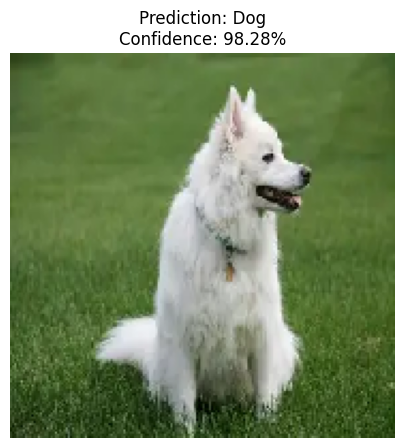

PREDICTION RESULT:
Predicted Class: Dog
Confidence: 98.28%
****************************************************************************************************


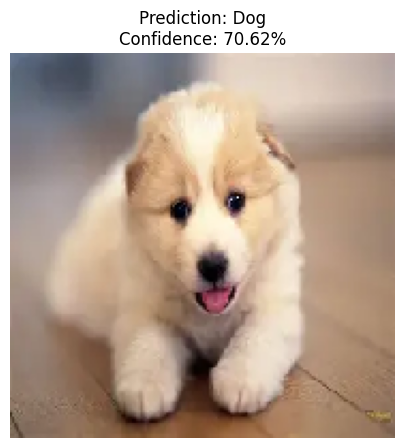

PREDICTION RESULT:
Predicted Class: Dog
Confidence: 70.62%
****************************************************************************************************


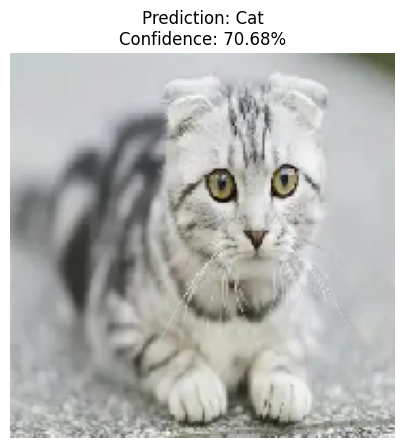

PREDICTION RESULT:
Predicted Class: Cat
Confidence: 70.68%
****************************************************************************************************


In [ ]:
predict_image(
    "/content/download (1).webp"
)

predict_image(
    "/content/OIP.webp"
)

predict_image(
    "/content/download.webp"
)

